# Music Data Analysis Pipeline

This notebook implements a data pipeline for analyzing long-term trends in music using Billboard Top 100 data, enriched with external metadata sources.

The workflow includes data ingestion, enrichment via APIs, transformation, and analysis of genre and tempo trends across multiple decades.

## System Overview

This project is structured as a lightweight data pipeline designed to process and analyze music chart data at scale.

### Pipeline Stages:
1. Data ingestion from Billboard datasets
2. Metadata enrichment via external APIs
3. Data cleaning and normalization
4. Aggregation and feature extraction
5. Trend analysis and visualization

The system handles both structured and semi-structured/unstructured data (API responses).

## Data Ingestion

Billboard Top 100 datasets are loaded and parsed to extract track-level information, including artist names and song titles.

These datasets serve as the foundation for downstream enrichment and analysis.

To enhance the dataset, external APIs are used:

- **MusicBrainz API** → genre classification
- **AcousticBrainz API** → tempo (BPM) data

This step introduces unstructured and semi-structured data, requiring transformation into a consistent format.

Note: API calls significantly impact runtime due to rate limits and request volume.

## Data Processing

Raw data is cleaned and normalized to ensure consistency across datasets.

Key steps include:
- Handling missing or incomplete data
- Normalizing genre labels using pattern matching and regex
- Structuring API responses into tabular format
- Converting temporal data for time-series analysis

This stage ensures the dataset is suitable for aggregation and analysis.

## Visualization

Visualizations are used to communicate trends effectively:

- Heatmaps for genre popularity over time
- Line charts for BPM trends
- Comparative plots across decades

These outputs provide intuitive insights into the dataset.

## System Considerations

- API calls introduce significant latency (~80+ minutes for full execution)
- Dataset size is constrained by API throughput and rate limits
- Tradeoffs exist between dataset completeness and runtime efficiency

Future improvements should focus on optimizing data retrieval and scaling processing.

## Future Improvements

- Implement caching or batching to reduce API overhead
- Parallelize API requests to improve performance
- Expand dataset coverage across all Billboard years
- Introduce machine learning for genre classification and trend prediction
- Convert pipeline into a scheduled or automated workflow

In [1]:
'''
These are my chosen modules,
I will be using regex to fix variance between music genre names (Pop Rock vs Pop-Rock),
Requests will be used to fetch APIs
Billboard to fetch the Top 100
Pandas and PLT for visualisation 
'''

import re
import time
import requests
import billboard
import pandas as pd
import matplotlib.pyplot as plt

/Users/adrian/Library/Mobile Documents/com~apple~CloudDocs/CU Boulder/2025/FALL25/INFO 2201/Final Project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
'''
To keep my testing time brief I used the end of the year of the beginning of each decade,
Employing too many charts would make it take decades to process, but this can be expanded upon for further analysis
'''
chart_1970 = billboard.ChartData(name='hot-100', date='1970-12-12', fetch=True)
chart_1980 = billboard.ChartData(name='hot-100', date='1980-12-12', fetch=True)
chart_1990 = billboard.ChartData(name='hot-100', date='1990-12-12', fetch=True)
chart_2000 = billboard.ChartData(name='hot-100', date='2000-12-12', fetch=True)
chart_2010 = billboard.ChartData(name='hot-100', date='2010-12-12', fetch=True)
chart_2020 = billboard.ChartData(name='hot-100', date='2020-12-12', fetch=True)

In [ ]:
'''
The way I formatted my code was mostly through OOP. 
I used the Track class to fetch all Track-related information for each entry in the chart
I had to re-do it a couple times, since I attempted to use the Spotify API (big mistake) to gather bpm data
What I wasn't aware of, was that apparently spotify stopped offering that last year,
I was forced to use AcousticBrainz instead which massively increased my process time
'''

def fetch_with_retry(url, params=None, headers=None, retries=5, delay=2):
    '''
    This function was something I had to forcibly learn about. While testing, I noticed that often my 
    peer would disconnect me. It was not due to a lack of identification (which I had), or spamming the fetch (I had a sleep timer)
    At the end of the day I just implemented a fetch + retry function to try a few times if connection fails
    '''

    # '_' is used as a throwaway variable to just dictate the loop to loop 5 times
    for _ in range(retries):
        try:
            response = requests.get(url, params=params, headers=headers, timeout=10)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException:
            time.sleep(delay)
    return None

class Track:
    def __init__(self, title, artist):
        '''
        This init function will set the attributes thrown into the object by my ChartData variables
        It will then initialize empty variables that will be populated later
        It ends by calling the get_song_data function, which will set an id for the chosen song
        If such id is presented (the database cannot account for every song),
        then the get_tag_data and get_bpm functions will be called to occupy the attributes
        '''


        self.title = title
        self.artist = artist
        self.song_data = None
        self.tags = None
        self.mbid = None
        self.bpm = None
        
        
        self.get_song_data()
        if self.mbid:
            self.get_bpm()

    def get_song_data(self):
        '''
        This function (and by extension all of the functions presented in this class)
        had to be set up in a way which would not crash the program or give me empty attributes,
        ruining the data analysis

        The function just returns the first result in a search
        for a recording of the title and artist attributes.
        It will then grab the song id and call the get_tag_data function
        '''


        url = 'https://musicbrainz.org/ws/2/recording/'
        params = {'query': f"'{self.title}' AND artist:'{self.artist}'", 'fmt': 'json'}
        headers = {'User-Agent': 'CU Boulder INFO2201 Final Project (sacioadrian@gmail.com)'}
        data = fetch_with_retry(url, params=params, headers=headers)
        if not data: return
        recordings = data.get('recordings')
        if not recordings: return
        self.song_data = recordings[0]
        self.mbid = self.song_data.get('id')
        if self.mbid:
            self.get_tag_data()

    def get_tag_data(self):
        '''
        This function just sets the tags attribute as the list of tags presented in each song (if they exist)
        '''

        url = f"https://musicbrainz.org/ws/2/recording/{self.mbid}"
        params = {'inc': 'tags', 'fmt': 'json'}
        headers = {'User-Agent': 'CU Boulder INFO2201 Final Project (sacioadrian@gmail.com)'}
        data = fetch_with_retry(url, params=params, headers=headers)
        if data:
            self.tags = data.get('tags')

    def get_bpm(self):
        '''
        This function will just grab the tempo for each song based on the id attribute
        Since MusicBrainz doesn't include tempo, AcousticBrainz is used instead
        It is an offshoot of MusicBrainz that used the same id system and 
        includes different type of information such as mood types etc. 
        I had to employ measures to stop the API call if no id attribute exists
        '''

        if not self.mbid: return
        url = f"https://acousticbrainz.org/api/v1/{self.mbid}/low-level"
        data = fetch_with_retry(url)
        if data:
            tempo = data.get("rhythm", {}).get("bpm")
            if tempo is not None:
                self.bpm = tempo

In [4]:
'''
This class is used to create the Track objects and append them to a list of objects.
With this I can control how many songs to fetch per chart, essentially controlling my test-time
My genre aggregator then creates a dictionary entry based on each genre of each object, so I can track
how many times each genre appears in the chart
My init function just automatically processes all the data
'''

class SongProcessor:
    def __init__(self, chart):
        self.chart = chart
        self.track_list = []
        self.tag_dict = {}
        self.track_aggregator()
        self.genre_aggregator()

    def track_aggregator(self):
        counter = 0
        for song in self.chart:
            track = Track(song.title, song.artist)
            if track.tags:
                self.track_list.append(track) 
                counter += 1
            if counter == 25: break
    
    def genre_aggregator(self):
        for track in self.track_list:
            for dictionary in track.tags:
                name = dictionary['name']
                combined = self.combined_genre(name)
                if combined not in self.tag_dict:
                    self.tag_dict[combined] = 1
                else:
                    self.tag_dict[combined] += 1
            

    def combined_genre(self, name):
        name = name.lower()
        name = re.sub(r'[/\-]', ' ', name)      
        name = re.sub(r'\s+', ' ', name)        
        name = name.strip()
        return name

In [ ]:
'''
Each year's ChartData is then sent through the Processor object 
and stored in a general song data variable for each year
'''

songs_1970 = SongProcessor(chart_1970)
songs_1980 = SongProcessor(chart_1980)
songs_1990 = SongProcessor(chart_1990)
songs_2000 = SongProcessor(chart_2000)
songs_2010 = SongProcessor(chart_2010)
songs_2020 = SongProcessor(chart_2020)

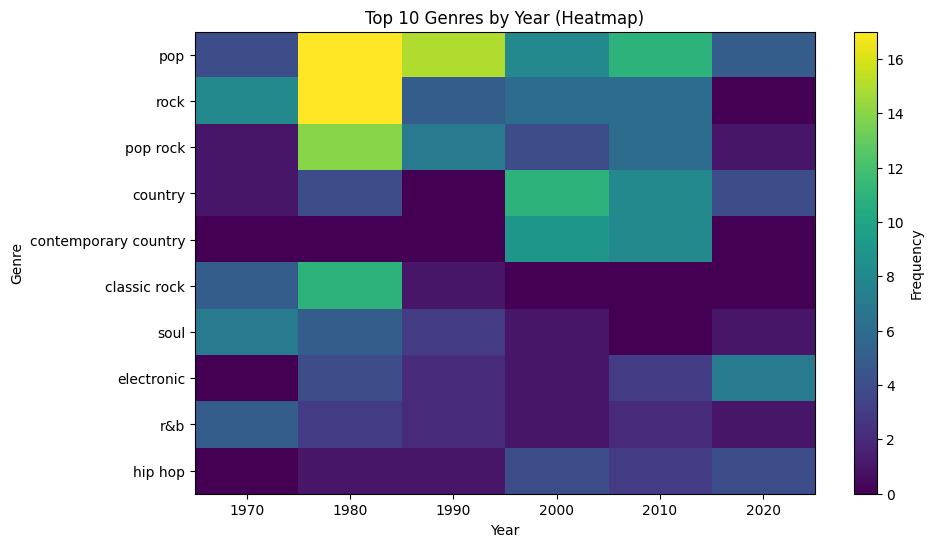

In [ ]:
'''
This cell is used to create a dataframe with my genre dictionary for each year
then (for brevity's sake) the top 10 genres of each year are used
to create a heatmap of how many repetitions of each track's genre is found in that day
'''


df = pd.DataFrame({1970: songs_1970.tag_dict, 1980: songs_1980.tag_dict, 1990: songs_1990.tag_dict, 2000: songs_2000.tag_dict, 2010: songs_2010.tag_dict, 2020: songs_2020.tag_dict}).fillna(0).astype(int)
top10 = df.sum(axis=1).sort_values(ascending=False).head(10).index
df_top10 = df.loc[top10]

plt.figure(figsize=(10, 6))
plt.imshow(df_top10.values, aspect='auto', cmap='viridis')

plt.xticks(range(len(df_top10.columns)), df_top10.columns)
plt.yticks(range(len(df_top10.index)), df_top10.index)

plt.colorbar(label="Frequency")
plt.title("Top 10 Genres by Year (Heatmap)")
plt.xlabel("Year")
plt.ylabel("Genre")
plt.show()

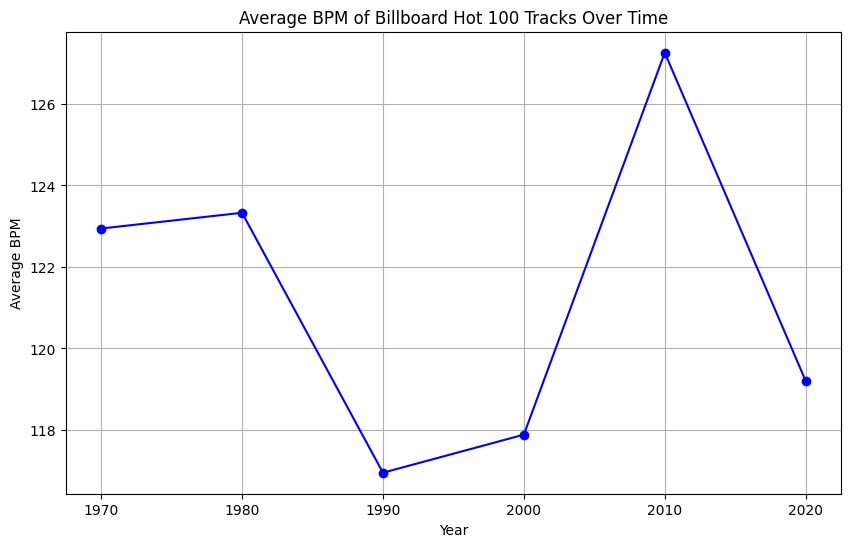

In [ ]:
'''
A similar process is employed to track the average bpm of each entry over time
'''

processors = { 1970: songs_1970, 1980: songs_1980, 1990: songs_1990, 2000: songs_2000, 2010: songs_2010, 2020: songs_2020}

all_tracks = []
for year, processor in processors.items():
    for track in processor.track_list:
        if track.bpm: 
            all_tracks.append({'year': year, 'bpm': track.bpm})

df = pd.DataFrame(all_tracks)
average_bpm = df.groupby('year')['bpm'].mean()

plt.figure(figsize=(10,6))
plt.plot(average_bpm.index, average_bpm.values, marker='o', linestyle='-', color='blue')
plt.title("Average BPM of Billboard Hot 100 Tracks Over Time")
plt.xlabel("Year")
plt.ylabel("Average BPM")
plt.xticks(average_bpm.index)
plt.grid(True)
plt.show()
plt.show()

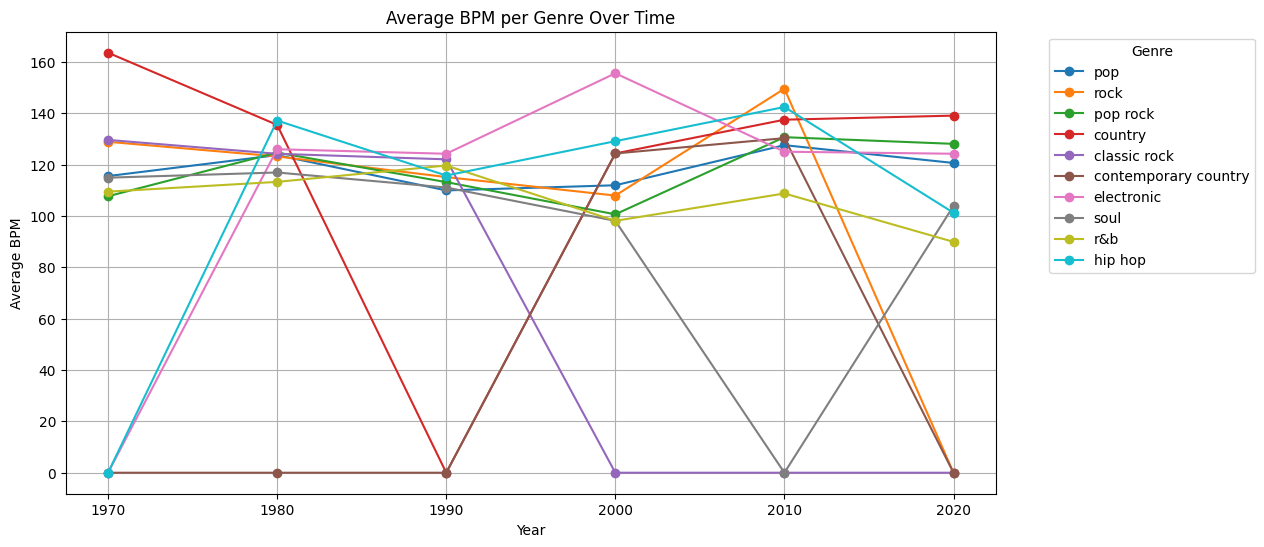

In [ ]:
'''
An empty list is initialized, so that the bpm and genre data of each entry
is appeneded as a dictionary to populate the dataframe, and visualized as the average bpm for each of the genres analysed
'''

records = []
for year, processor in processors.items():
    for track in processor.track_list:
        if track.bpm and track.tags:
            for tag in track.tags:
                genre = tag['name'].lower().strip()
                genre = genre.replace('/', ' ').replace('-', ' ')
                records.append({
                    "year": year,
                    "genre": genre,
                    "bpm": track.bpm
                })

df = pd.DataFrame(records)
avg_bpm_genre = df.groupby(['genre', 'year'])['bpm'].mean().unstack(fill_value=0)


top_genres = df['genre'].value_counts().head(10).index
avg_bpm_top10 = avg_bpm_genre.loc[top_genres]


avg_bpm_top10.T.plot(kind='line', figsize=(12,6), marker='o')
plt.title("Average BPM per Genre Over Time")
plt.xlabel("Year")
plt.ylabel("Average BPM")
plt.xticks(list(processors.keys()))
plt.grid(True)
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1))
plt.show()

## In the event that the plots aren't showing when opening this notebook, below I will show snapshots of the plot with its accompanied code

This heatmap explores the evolution of the most popular genres for the chart. We can see the peak of rock music during 1980  and the steady decline of classic rock along the years. Electronic and country music ended up becoming more popular in recent years and we can notice the rise of hip hop as a genre
![Top 10 Genres by Year](Top_10_Genres_by_Year.png)

This chart is based on the average BPM for all of the songs in each chart, and we can see that the 2010s was distinct for its fast music-listening habit, whilst the 1990s and 2000s might be populated with ballads and rnb with its slow tempo
![Average BPM Over Time](Average_BPM_Over_Time.png)

Both charts are then put together to explore the evolution of the genres themselves, and if each genre has sped up or slowed down over time. With this, we can also see the birth of genres such as Contemporary Country betweeen 1990-2000, and again the death of rock between the 2010s and 2020s in the Top 100 charts. 
![Average BPM by Genre](Average_BPM_by_Genre.png)